# Portfolio Optimization: Monte Carlo Simulation
**Author:** Michael Owen A.  
**Date:** June 2026

## Overview
This project aims to optimize asset allocation using **Monte Carlo simulations**. By simulating 500,000 potential portfolio weight combinations, we map the **Efficient Frontier** to identify the allocation that maximizes the **Sharpe Ratio**—balancing risk against expected return.

### Methodology
1. **Data Acquisition**: Fetching 5 years of historical data from Yahoo Finance for a basket of high-growth assets.
2. **Simulation**: Using random sampling to generate thousands of possible portfolio configurations.
3. **Optimization**: Applying *Modern Portfolio Theory* (MPT) principles to evaluate the risk-return profile of each portfolio.

In [1]:
# --- Import Libraries --- #
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

## Mathematical Framework

The portfolios are evaluated based on three core metrics derived from Modern Portfolio Theory:

**1. Expected Portfolio Return**
$$E(R_p) = \sum_{i=1}^{n} w_i E(R_i)$$

**2. Portfolio Volatility**
$$\sigma_p = \sqrt{w^T \Sigma w}$$
*Where:*
* $w$ is the vector of asset weights.
* $\Sigma$ is the covariance matrix of asset returns.

**3. Sharpe Ratio**
A measure of risk-adjusted return used to identify the most efficient portfolio:
$$Sharpe = \frac{E(R_p) - R_f}{\sigma_p}$$

In [2]:
# --- Configuration --- #
assets = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'AVGO', 'BRK-B']
start_date = '2021-06-24'
end_date = '2026-06-24'
num_portfolios = 500000
trading_days = 252

def get_data(assets, start, end):
    df = yf.download(assets, start=start, end=end)['Close']
    try:
        tnx = yf.Ticker("^TNX")
        tnx_history = tnx.history(period='5d')
        if not tnx_history.empty:
            raw_rf = tnx_history['Close'].iloc[-1]
            rf_rate = float(raw_rf / 100)
        else:
            rf_rate = 0.04
    except Exception as e:
        print(f"Failed to retrieve ^TNX ({e}). Using default rf of 0.04")
        rf_rate = 0.04
    
    return df.dropna(axis=1, how='all'), rf_rate

def simulate_portfolios_vectorized(returns, cov_matrix, num_portfolios, rf):
    num_assets = len(returns.columns)

    weights = np.random.random((num_portfolios, num_assets))
    weights = weights / np.sum(weights, axis=1)[:, np.newaxis]

    exp_returns = returns.mean().values * trading_days
    portfolio_returns = np.dot(weights, exp_returns)

    portfolio_variance = np.sum(np.matmul(weights, cov_matrix.values) * weights, axis=1)
    portfolio_volatility = np.sqrt(portfolio_variance) * np.sqrt(trading_days)

    sharpe_ratios = (portfolio_returns - rf) / portfolio_volatility

    results = np.vstack((portfolio_returns, portfolio_volatility, sharpe_ratios))
    
    return results, weights

[*********************100%***********************]  7 of 7 completed


Risk Free Rate:  4.38%
Max Sharpe Ratio: 1.2276
Expected Return: 42.31%
Volatility: 30.90%

Optimal Asset Allocation:
AAPL: 0.06%
AMZN: 0.91%
AVGO: 39.64%
BRK-B: 25.83%
GOOG: 4.68%
MSFT: 2.10%
NVDA: 26.78%
Plot successfully saved as 'efficient_frontier.png'


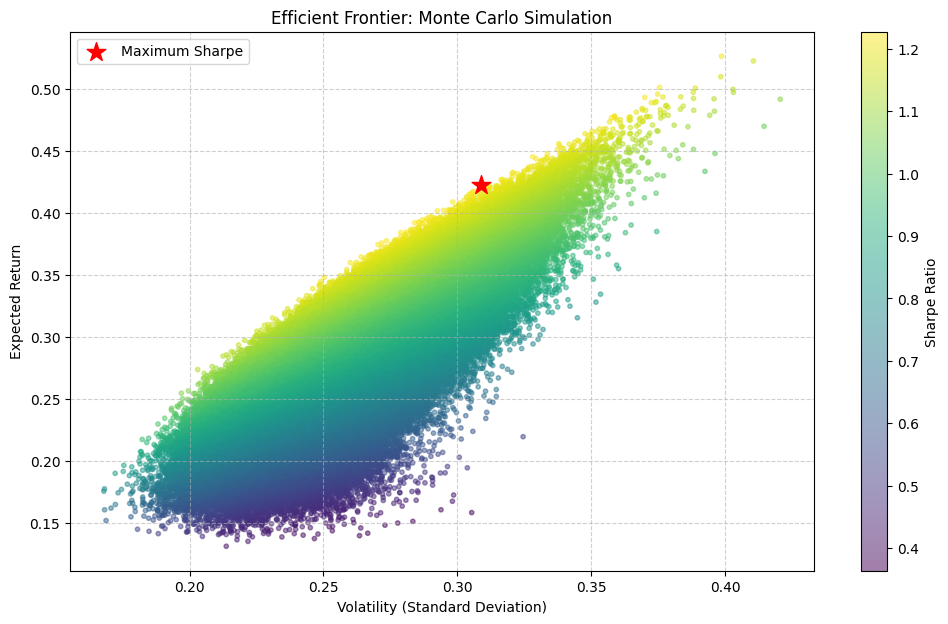

In [3]:
# --- Execution and Save --- #

# Data Preparation
data, rf_rate = get_data(assets, start_date, end_date)
returns = data.pct_change().dropna()
cov_matrix = returns.cov()

active_assets = returns.columns.tolist()

results, weights_record = simulate_portfolios_vectorized(returns, cov_matrix, num_portfolios, rf_rate)

max_sharpe_idx = np.argmax(results[2])
best_weights = weights_record[max_sharpe_idx, :]

print(f"Risk Free Rate: {rf_rate: .2%}")
print(f"Max Sharpe Ratio: {results[2, max_sharpe_idx]:.4f}")
print(f"Expected Return: {results[0, max_sharpe_idx]:.2%}")
print(f"Volatility: {results[1, max_sharpe_idx]:.2%}\n")

print("Optimal Asset Allocation:")
for asset, weight in zip(active_assets, best_weights):
    print(f"{asset}: {weight:.2%}")

plt.figure(figsize=(12, 7))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], color='red', marker='*', s=200, label='Maximum Sharpe')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier: Monte Carlo Simulation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('efficient_frontier.png', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'efficient_frontier.png'")
plt.show()

### Interpretation & Asset Dominance
The simulation yields a Maximum Sharpe Ratio of **1.2276**, with an Expected Return of **42.31%** and an annualized Volatility of **30.90%**. 

Interestingly, the optimizer heavily favors three specific assets:
* **AVGO (39.64%)** and **NVDA (26.78%)**: Driven by the massive technology and AI sector tailwinds between 2021 and 2026, these assets offer substantial expected returns that justify their high volatility.
* **BRK-B (25.83%)**: Acts as a stabilizing anchor in the portfolio, providing low-volatility diversification against the aggressive tech heavyweights.
* **AAPL, AMZN, MSFT, GOOG**: Receive minimal allocations (under 5% each), indicating that from a purely mathematical risk-adjusted return perspective over this 5-year window, their marginal diversification benefit did not outperform a concentrated bet on AVGO, NVDA, and BRK-B.

### Project Takeaway
This simulation provides a robust, data-driven baseline for asset allocation. It successfully proves that an intuitive "equal-weight" distribution (e.g., ~14% each) would be highly sub-optimal compared to this calculated Maximum Sharpe configuration, allowing us to quantitatively maximize returns while explicitly accounting for the 4.38% risk-free rate environment.